In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import MDS, TSNE

In [3]:
# Roulade point generator functions
def uniform_spiral(density=3, steps=100):
    x, y = [], []
    for i in range(steps):
        x.append(
            (i / steps) ** 0.5 * math.cos((i / steps) ** 0.5 * density * np.pi * 2)
        )
        y.append(
            (i / steps) ** 0.5 * math.sin((i / steps) ** 0.5 * density * np.pi * 2)
        )
    return x, y


def uniform_roll(xli, yli, width=7, angle=0.25, density=5, noise_factor=0.05):
    nx, ny, nz, d = [], [], [], []
    d1 = [((x**2 + y**2) ** 0.5) for x, y in zip(xli, yli)]
    for i in range(density):
        nx.extend(
            [
                (width + x) * math.cos(angle * i / density * np.pi * 2)
                + (random.random() - 0.5) * noise_factor
                for x in xli
            ]
        )
        ny.extend(
            [
                (width + x) * math.sin(angle * i / density * np.pi * 2)
                + (random.random() - 0.5) * noise_factor
                for x in xli
            ]
        )
        nz.extend(yli)
        d.extend(d1)
    return nx, ny, nz, d


def roll_generator(
    to_array=True, spiral_density=3, spiral_steps=20, width=7, angle=0.3, density=5
):
    x, y = uniform_spiral(density=spiral_density, steps=spiral_steps)
    x, y, z, d = uniform_roll(x, y, width=width, angle=angle, density=density)

    if to_array:
        return np.array([x, y, z]).T, d
    else:
        return x, y, z, d

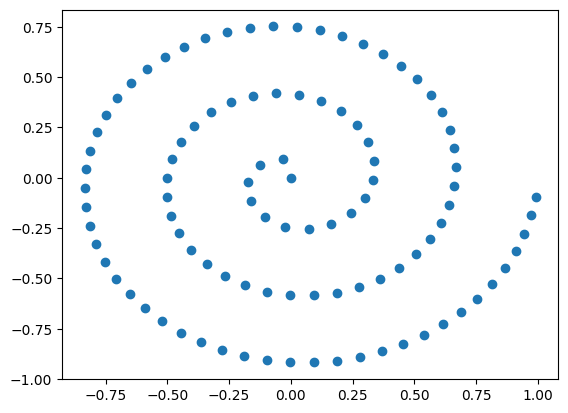

In [11]:
x_spiral, y_spiral = uniform_spiral()
plt.scatter(x_spiral, y_spiral)

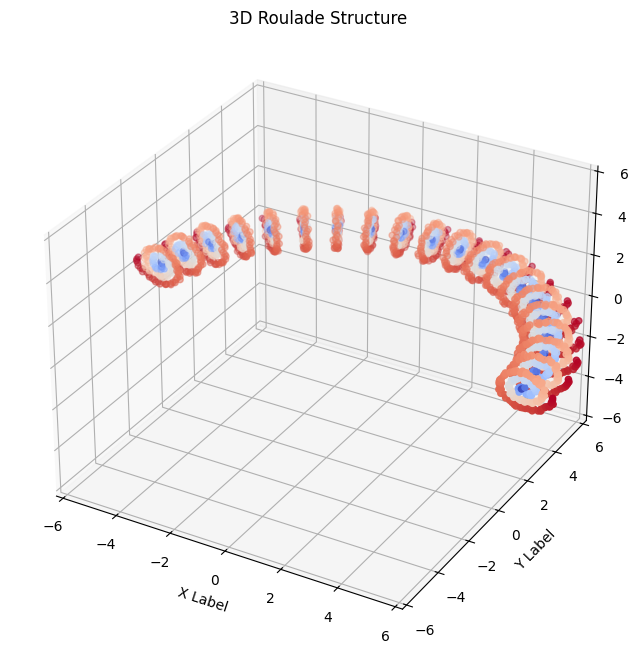

In [ ]:
def plot_roulade(x, y, z, d=None):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel("X Label")
    ax.set_ylabel("Y Label")
    ax.set_zlabel("Z Label")
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    plt.title("3D Roulade Structure")
    plt.show()

# Generate and visualize the roulade
xl, yl = uniform_spiral()
x, y, z, d = uniform_roll(xl, yl, width=7, angle=0.5, density=20, noise_factor=0.15)
plot_roulade(x, y, z, d=d)

## PCA

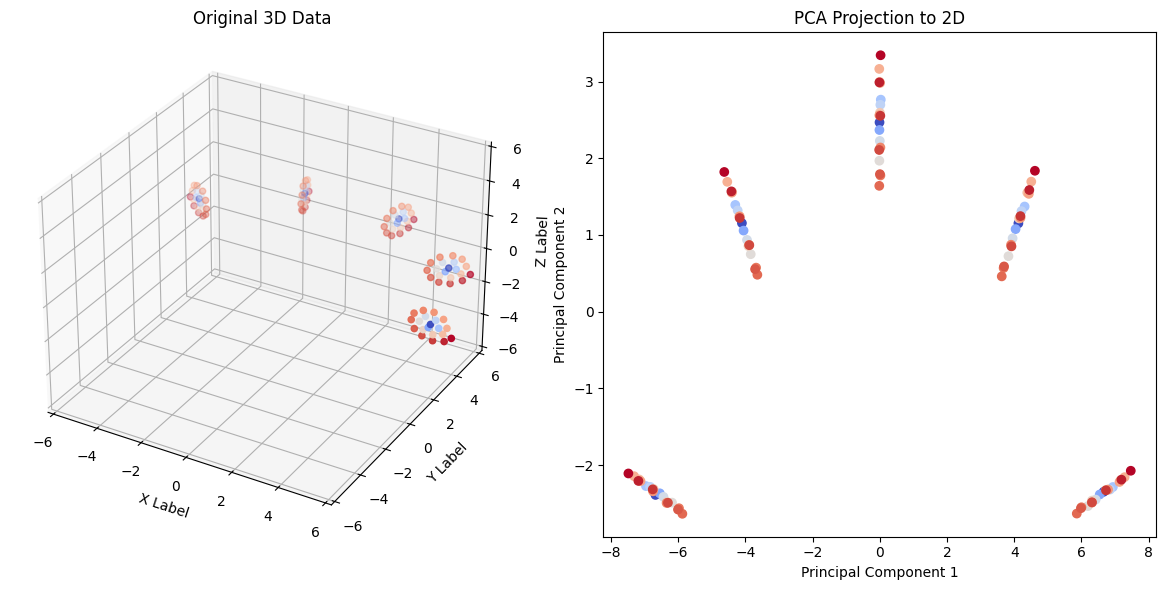

In [14]:
def show_PCA(spiral_density=3, spiral_steps=20, width=7, angle=0.5, roll_density=5):
    fig = plt.figure(figsize=(12, 6))
    x, y, z, d = roll_generator(
        to_array=False,
        spiral_density=spiral_density,
        spiral_steps=spiral_steps,
        width=width,
        angle=angle,
        density=roll_density,
    )

    # Plot original 3D data
    ax = fig.add_subplot(121, projection="3d")
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel("X Label")
    ax.set_ylabel("Y Label")
    ax.set_zlabel("Z Label")
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    ax.set_title("Original 3D Data")

    # PCA transformation
    ax2 = fig.add_subplot(122)
    points, d = roll_generator(
        to_array=True,
        spiral_density=spiral_density,
        spiral_steps=spiral_steps,
        width=width,
        angle=angle,
        density=roll_density,
    )

    embedding = PCA(n_components=2)
    points_transformed = embedding.fit_transform(points)
    points_transformed_t = points_transformed.T

    ax2.scatter(
        points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm
    )
    ax2.set_xlabel("Principal Component 1")
    ax2.set_ylabel("Principal Component 2")
    ax2.set_title("PCA Projection to 2D")

    plt.tight_layout()
    plt.show()
#

show_PCA()

## Kernel PCA

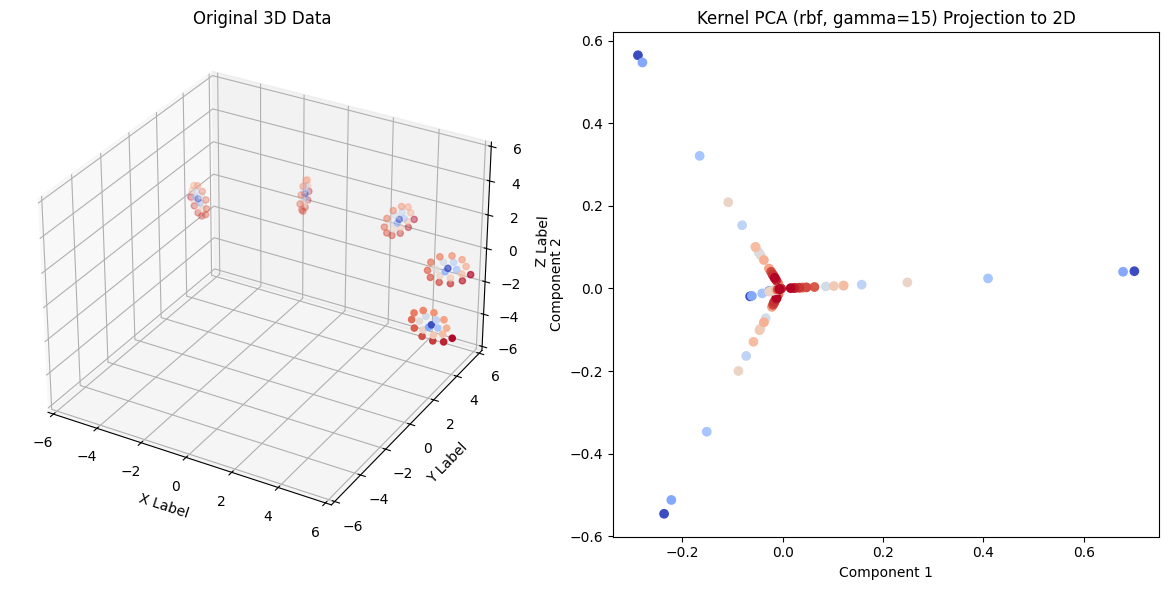

In [6]:
def show_KernelPCA(
    spiral_density=3,
    spiral_steps=20,
    width=7,
    angle=0.5,
    roll_density=5,
    kernel="rbf",
    gamma=15,
):
    fig = plt.figure(figsize=(12, 6))
    x, y, z, d = roll_generator(
        to_array=False,
        spiral_density=spiral_density,
        spiral_steps=spiral_steps,
        width=width,
        angle=angle,
        density=roll_density,
    )

    # Plot original 3D data
    ax = fig.add_subplot(121, projection="3d")
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel("X Label")
    ax.set_ylabel("Y Label")
    ax.set_zlabel("Z Label")
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    ax.set_title("Original 3D Data")

    # Kernel PCA transformation
    ax2 = fig.add_subplot(122)
    points, d = roll_generator(
        to_array=True,
        spiral_density=spiral_density,
        spiral_steps=spiral_steps,
        width=width,
        angle=angle,
        density=roll_density,
    )

    embedding = KernelPCA(n_components=2, kernel=kernel, gamma=gamma)
    points_transformed = embedding.fit_transform(points)
    points_transformed_t = points_transformed.T

    ax2.scatter(
        points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm
    )
    ax2.set_xlabel("Component 1")
    ax2.set_ylabel("Component 2")
    ax2.set_title(f"Kernel PCA ({kernel}, gamma={gamma}) Projection to 2D")

    plt.tight_layout()
    plt.show()
#

show_KernelPCA()

## MDS

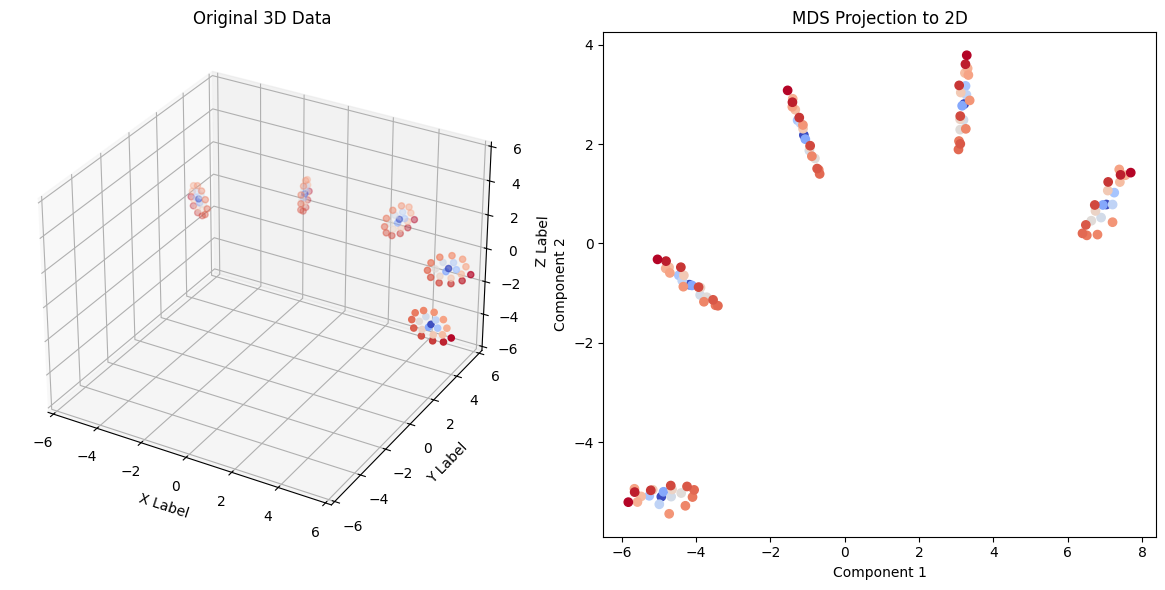

In [10]:
def show_MDS(spiral_density=3, spiral_steps=20, width=7, angle=0.5, roll_density=5):
    fig = plt.figure(figsize=(12, 6))
    x, y, z, d = roll_generator(
        to_array=False,
        spiral_density=spiral_density,
        spiral_steps=spiral_steps,
        width=width,
        angle=angle,
        density=roll_density,
    )

    # Plot original 3D data
    ax = fig.add_subplot(121, projection="3d")
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel("X Label")
    ax.set_ylabel("Y Label")
    ax.set_zlabel("Z Label")
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    ax.set_title("Original 3D Data")

    # MDS transformation
    ax2 = fig.add_subplot(122)
    points, d = roll_generator(
        to_array=True,
        spiral_density=spiral_density,
        spiral_steps=spiral_steps,
        width=width,
        angle=angle,
        density=roll_density,
    )

    embedding = MDS(n_components=2)
    points_transformed = embedding.fit_transform(points)
    points_transformed_t = points_transformed.T

    ax2.scatter(
        points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm
    )
    ax2.set_xlabel("Component 1")
    ax2.set_ylabel("Component 2")
    ax2.set_title("MDS Projection to 2D")

    plt.tight_layout()
    plt.show()
#

show_MDS()

## t-SNE

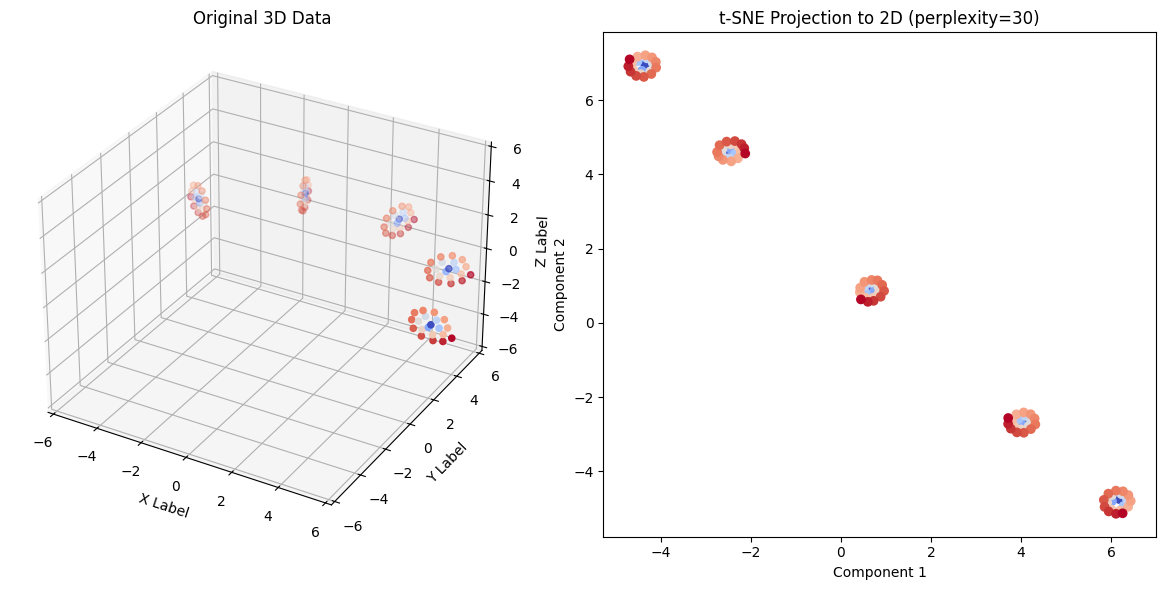

In [15]:
def show_tSNE(
    spiral_density=3,
    spiral_steps=20,
    width=7,
    angle=0.5,
    roll_density=5,
    metric="euclidean",
    perplexity=30,
):
    fig = plt.figure(figsize=(12, 6))
    x, y, z, d = roll_generator(
        to_array=False,
        spiral_density=spiral_density,
        spiral_steps=spiral_steps,
        width=width,
        angle=angle,
        density=roll_density,
    )

    # Plot original 3D data
    ax = fig.add_subplot(121, projection="3d")
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel("X Label")
    ax.set_ylabel("Y Label")
    ax.set_zlabel("Z Label")
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    ax.set_title("Original 3D Data")

    # t-SNE transformation
    ax2 = fig.add_subplot(122)
    points, d = roll_generator(
        to_array=True,
        spiral_density=spiral_density,
        spiral_steps=spiral_steps,
        width=width,
        angle=angle,
        density=roll_density,
    )

    embedding = TSNE(n_components=2, metric=metric, perplexity=perplexity)
    points_transformed = embedding.fit_transform(points)
    points_transformed_t = points_transformed.T

    ax2.scatter(
        points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm
    )
    ax2.set_xlabel("Component 1")
    ax2.set_ylabel("Component 2")
    ax2.set_title(f"t-SNE Projection to 2D (perplexity={perplexity})")

    plt.tight_layout()
    plt.show()
#

show_tSNE()